ディレクトリ 'C:\Users\kyohe\Aerial_Photo_Classifier\20251209Data\PatchPNG' をスキャン中...

合計で 16690 枚の画像を取得しました

階級ごとの画像枚数 (階級幅: 0.1):
--------------------------------------------------
[0.40 - 0.50): 2 枚
[0.50 - 0.60): 43 枚
[0.60 - 0.70): 28 枚
[0.70 - 0.80): 26 枚
[0.80 - 0.90): 9 枚
[0.90 - 1.00): 2726 枚
[1.00 - 1.10): 13671 枚
[1.10 - 1.20): 50 枚
[1.20 - 1.30): 28 枚
[1.30 - 1.40): 13 枚
[1.40 - 1.50): 25 枚
[1.50 - 1.60): 27 枚
[1.60 - 1.70): 14 枚
[1.70 - 1.80): 15 枚
[1.80 - 1.90): 10 枚
[1.90 - 2.00): 3 枚

統計情報:
  最小縦横比: 0.4906
  最大縦横比: 1.9630
  平均縦横比: 1.0022
  中央値縦横比: 1.0000
  標準偏差: 0.0585

[0.90 - 1.00)と[1.00 - 1.10)以外の階級に属する 293 枚の画像をCSVに出力しました:
  出力先: C:\Users\kyohe\Aerial_Photo_Classifier\20251209Data\PatchPNG\abnormal_aspect_ratio_images.csv


C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 32294 (\N{CJK UNIFIED IDEOGRAPH-7E26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 27178 (\N{CJK UNIFIED IDEOGRAPH-6A2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2965445373.py:138: UserWarning: Glyph 26522 (\

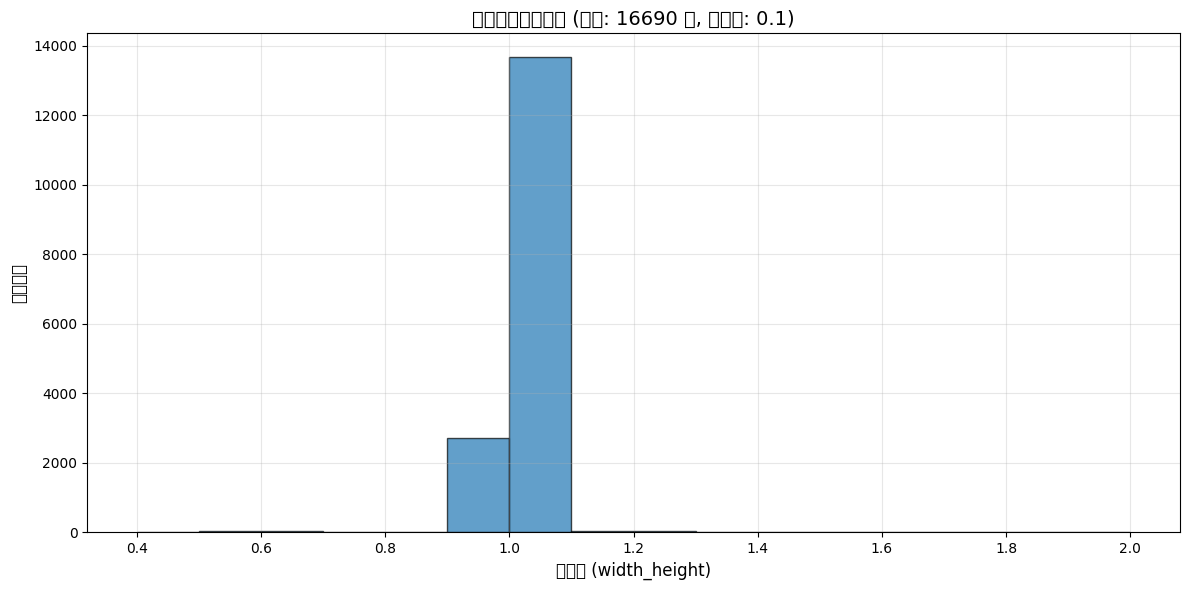

In [3]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import pandas as pd

def analyze_aspect_ratios(directory_path, bin_increment=0.1, aspect_ratio_type='width_height'):
    """
    指定されたディレクトリ内のすべての画像の縦横比を分析し、ヒストグラムを作成する
    
    Parameters:
    -----------
    directory_path : str
        画像が含まれるディレクトリのパス
    bin_increment : float
        ヒストグラムの階級幅（デフォルト: 0.1）
    aspect_ratio_type : str
        'width_height' (width/height) または 'height_width' (height/width)
    """
    # サポートされている画像形式
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.gif', '.webp'}
    
    # すべての画像ファイルを取得
    image_files = []
    directory = Path(directory_path)
    
    if not directory.exists():
        print(f"エラー: ディレクトリ '{directory_path}' が見つかりません")
        return
    
    print(f"ディレクトリ '{directory_path}' をスキャン中...")
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            if Path(file).suffix.lower() in image_extensions:
                image_files.append(Path(root) / file)
    
    total_images = len(image_files)
    print(f"\n合計で {total_images} 枚の画像を取得しました")
    
    if total_images == 0:
        print("画像が見つかりませんでした")
        return
    
    # 縦横比を計算（ファイルパスと一緒に保持）
    aspect_ratios = []
    image_data = []  # (ファイルパス, 縦横比) のリスト
    failed_images = []
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                if aspect_ratio_type == 'width_height':
                    aspect_ratio = width / height
                else:
                    aspect_ratio = height / width
                aspect_ratios.append(aspect_ratio)
                image_data.append((str(img_path), aspect_ratio))
        except Exception as e:
            failed_images.append((str(img_path), str(e)))
    
    if failed_images:
        print(f"\n警告: {len(failed_images)} 枚の画像の読み込みに失敗しました")
        for img_path, error in failed_images[:5]:  # 最初の5つだけ表示
            print(f"  {img_path}: {error}")
        if len(failed_images) > 5:
            print(f"  ... 他 {len(failed_images) - 5} 件")
    
    if not aspect_ratios:
        print("有効な画像が見つかりませんでした")
        return
    
    # ヒストグラムの階級を設定
    min_ratio = min(aspect_ratios)
    max_ratio = max(aspect_ratios)
    
    # 階級の範囲を決定（minからmaxまで、bin_increment刻み）
    bins = np.arange(
        np.floor(min_ratio / bin_increment) * bin_increment,
        np.ceil(max_ratio / bin_increment) * bin_increment + bin_increment,
        bin_increment
    )
    
    # ヒストグラムを計算
    counts, bin_edges = np.histogram(aspect_ratios, bins=bins)
    
    # 階級ごとの画像枚数を表示
    print(f"\n階級ごとの画像枚数 (階級幅: {bin_increment}):")
    print("-" * 50)
    
    for i, (count, left_edge, right_edge) in enumerate(zip(counts, bin_edges[:-1], bin_edges[1:])):
        if count > 0:  # 画像がある階級のみ表示
            print(f"[{left_edge:.2f} - {right_edge:.2f}): {count} 枚")
    
    # [0.90 - 1.10)以外の階級に属する画像を収集
    abnormal_images = []  # 異常な縦横比の画像を保存（[0.90 - 1.10)以外）
    for img_path, aspect_ratio in image_data:
        # 縦横比が[0.90, 1.10)の範囲外かどうかを判定
        if aspect_ratio < 0.90 or aspect_ratio >= 1.10:
            # どの階級に属するかを判定
            for left_edge, right_edge in zip(bin_edges[:-1], bin_edges[1:]):
                if left_edge <= aspect_ratio < right_edge:
                    abnormal_images.append({
                        'ファイルパス': img_path,
                        '縦横比': aspect_ratio,
                        '階級範囲': f"[{left_edge:.2f} - {right_edge:.2f})"
                    })
                    break
    
    # 統計情報を表示
    print(f"\n統計情報:")
    print(f"  最小縦横比: {min_ratio:.4f}")
    print(f"  最大縦横比: {max_ratio:.4f}")
    print(f"  平均縦横比: {np.mean(aspect_ratios):.4f}")
    print(f"  中央値縦横比: {np.median(aspect_ratios):.4f}")
    print(f"  標準偏差: {np.std(aspect_ratios):.4f}")
    
    # 異常な縦横比の画像をCSVに出力
    if abnormal_images:
        df = pd.DataFrame(abnormal_images)
        csv_path = Path(directory_path) / 'abnormal_aspect_ratio_images.csv'
        df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"\n[0.90 - 1.00)と[1.00 - 1.10)以外の階級に属する {len(abnormal_images)} 枚の画像をCSVに出力しました:")
        print(f"  出力先: {csv_path}")
    else:
        print(f"\n異常な縦横比の画像は見つかりませんでした")
    
    # ヒストグラムをプロット
    plt.figure(figsize=(12, 6))
    plt.hist(aspect_ratios, bins=bins, edgecolor='black', alpha=0.7)
    plt.xlabel(f'縦横比 ({aspect_ratio_type})', fontsize=12)
    plt.ylabel('画像枚数', fontsize=12)
    plt.title(f'画像の縦横比分布 (合計: {total_images} 枚, 階級幅: {bin_increment})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {
        'total_images': total_images,
        'aspect_ratios': aspect_ratios,
        'image_data': image_data,
        'counts': counts,
        'bin_edges': bin_edges,
        'abnormal_images': abnormal_images,
        'statistics': {
            'min': min_ratio,
            'max': max_ratio,
            'mean': np.mean(aspect_ratios),
            'median': np.median(aspect_ratios),
            'std': np.std(aspect_ratios)
        }
    }


directory_path = r"C:\Users\kyohe\Aerial_Photo_Classifier\20251209Data\PatchPNG"
result = analyze_aspect_ratios(directory_path, bin_increment=0.1)

In [ ]:
# 使用例
# ディレクトリパスを指定して実行してください

# 例1: デフォルト設定（階級幅0.1）
# directory_path = r"C:\path\to\your\images"
# result = analyze_aspect_ratios(directory_path)

# 例2: 階級幅を細かく設定（0.05）
# result = analyze_aspect_ratios(directory_path, bin_increment=0.05)

# 例3: 階級幅を粗く設定（0.2）
# result = analyze_aspect_ratios(directory_path, bin_increment=0.2)

# 例4: height/width の比率を使用
# result = analyze_aspect_ratios(directory_path, bin_increment=0.1, aspect_ratio_type='height_width')

ディレクトリ 'C:\Users\kyohe\Aerial_Photo_Classifier\20251209Data\Train_KFold' をスキャン中...

合計で 3926 枚のPNG画像を取得しました

統計情報:
  最小透明ピクセル割合: 0.00%
  最大透明ピクセル割合: 45.17%
  平均透明ピクセル割合: 3.81%
  中央値透明ピクセル割合: 3.77%
  標準偏差: 2.51%

透明ピクセル割合 >= 6% の画像: 136 枚

透明ピクセル割合の階級ごとの画像枚数 (階級幅: 1.0%):
--------------------------------------------------
[0.00% - 1.00%): 179 枚
[1.00% - 2.00%): 307 枚
[2.00% - 3.00%): 653 枚
[3.00% - 4.00%): 1082 枚
[4.00% - 5.00%): 966 枚
[5.00% - 6.00%): 603 枚
[6.00% - 7.00%): 62 枚
[7.00% - 8.00%): 19 枚
[8.00% - 9.00%): 4 枚
[9.00% - 10.00%): 1 枚
[10.00% - 11.00%): 1 枚
[11.00% - 12.00%): 2 枚
[12.00% - 13.00%): 7 枚
[13.00% - 14.00%): 4 枚
[14.00% - 15.00%): 3 枚
[15.00% - 16.00%): 3 枚
[16.00% - 17.00%): 3 枚
[17.00% - 18.00%): 2 枚
[18.00% - 19.00%): 1 枚
[19.00% - 20.00%): 1 枚
[20.00% - 21.00%): 1 枚
[21.00% - 22.00%): 1 枚
[22.00% - 23.00%): 3 枚
[23.00% - 24.00%): 3 枚
[24.00% - 25.00%): 1 枚
[25.00% - 26.00%): 3 枚
[27.00% - 28.00%): 3 枚
[28.00% - 29.00%): 1 枚
[30.00% - 31.00%): 1 枚
[31.00% - 32.00

C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 12500 (\N{KATAKANA LETTER PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyohe\AppData\Local\Temp\ipykernel_3852\2138881155.py:162: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) m

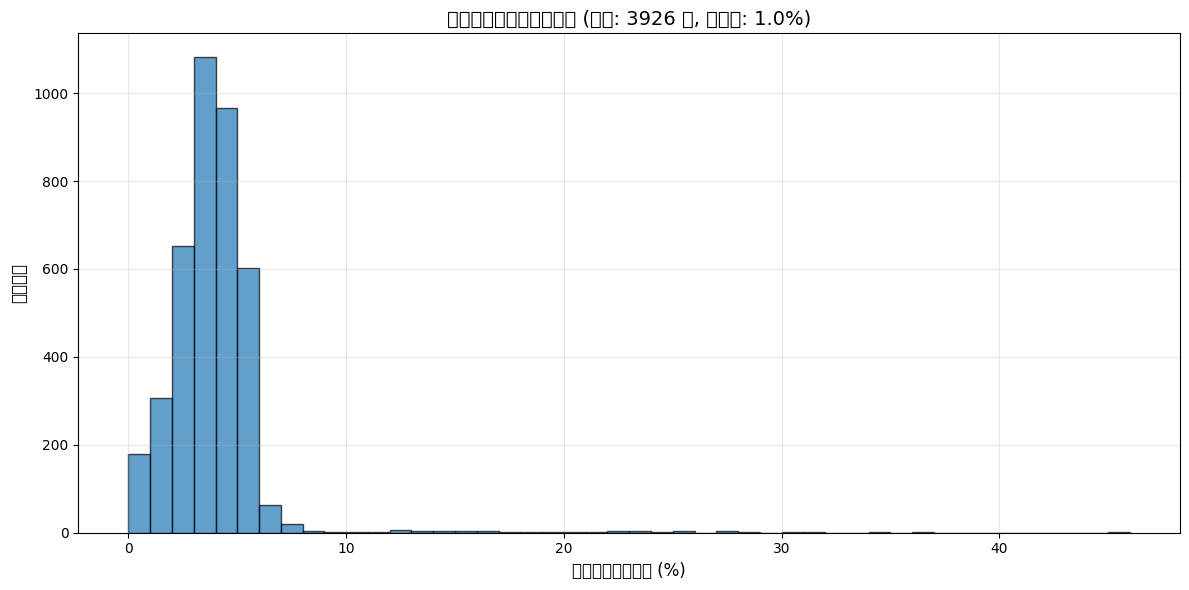

In [10]:
def analyze_transparent_images(directory_path, transparent_ratio_threshold=0.0, bin_increment=1.0):
    """
    指定されたディレクトリ内のPNG画像のαチャンネルを分析し、透明ピクセル割合でヒストグラムを作成する
    
    Parameters:
    -----------
    directory_path : str
        画像が含まれるディレクトリのパス
    transparent_ratio_threshold : float
        透明ピクセル割合の閾値（パーセント、デフォルト: 0.0）
        この値以上の透明ピクセル割合を持つ画像をCSVに出力
    bin_increment : float
        ヒストグラムの階級幅（パーセント、デフォルト: 1.0）
    """
    # PNGファイルのみを取得
    image_files = []
    directory = Path(directory_path)
    
    if not directory.exists():
        print(f"エラー: ディレクトリ '{directory_path}' が見つかりません")
        return
    
    print(f"ディレクトリ '{directory_path}' をスキャン中...")
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            if Path(file).suffix.lower() == '.png':
                image_files.append(Path(root) / file)
    
    total_images = len(image_files)
    print(f"\n合計で {total_images} 枚のPNG画像を取得しました")
    
    if total_images == 0:
        print("PNG画像が見つかりませんでした")
        return
    
    # αチャンネルを分析
    transparent_images = []  # 透明な画像の情報
    image_alpha_data = []  # すべての画像のα情報
    failed_images = []
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                                # 画像サイズを取得して縦横比を計算
                width, height = img.size
                aspect_ratio = width / height
                

                # RGBAまたはLAモードに変換
                if img.mode in ('RGBA', 'LA'):
                    # αチャンネルを取得
                    alpha_channel = np.array(img.split()[-1])  # 最後のチャンネルがα
                    min_alpha = alpha_channel.min()
                    max_alpha = alpha_channel.max()
                    mean_alpha = alpha_channel.mean()
                    
                    # 透明なピクセルの割合を計算
                    transparent_pixel_count = np.sum(alpha_channel < transparent_ratio_threshold)
                    total_pixels = alpha_channel.size
                    transparent_ratio = (transparent_pixel_count / total_pixels) * 100
                    
                    image_alpha_data.append({
                        'ファイルパス': str(img_path),
                        '最小α値': int(min_alpha),
                        '最大α値': int(max_alpha),
                        '平均α値': float(mean_alpha),
                        '透明ピクセル数': int(transparent_pixel_count),
                        '総ピクセル数': int(total_pixels),
                        '透明ピクセル割合(%)': float(transparent_ratio),
                        '縦横比': float(aspect_ratio)
                    })
                    
                    # 透明ピクセル割合が閾値以上の画像を抽出（後で判定）
                    # ここではデータを収集するだけ
                else:
                    # αチャンネルがない画像（RGB、Lなど）
                    image_alpha_data.append({
                        'ファイルパス': str(img_path),
                        '最小α値': 255,  # 不透明として扱う
                        '最大α値': 255,
                        '平均α値': 255.0,
                        '透明ピクセル数': 0,
                        '総ピクセル数': img.size[0] * img.size[1],
                        '透明ピクセル割合(%)': 0.0,
                        '縦横比': float(aspect_ratio),
                    })
        except Exception as e:
            failed_images.append((str(img_path), str(e)))
    
    if failed_images:
        print(f"\n警告: {len(failed_images)} 枚の画像の読み込みに失敗しました")
        for img_path, error in failed_images[:5]:  # 最初の5つだけ表示
            print(f"  {img_path}: {error}")
        if len(failed_images) > 5:
            print(f"  ... 他 {len(failed_images) - 5} 件")
    
    if not image_alpha_data:
        print("有効な画像が見つかりませんでした")
        return
    
    # 統計情報を表示
    transparent_ratios = [data['透明ピクセル割合(%)'] for data in image_alpha_data]
    
    print(f"\n統計情報:")
    print(f"  最小透明ピクセル割合: {min(transparent_ratios):.2f}%")
    print(f"  最大透明ピクセル割合: {max(transparent_ratios):.2f}%")
    print(f"  平均透明ピクセル割合: {np.mean(transparent_ratios):.2f}%")
    print(f"  中央値透明ピクセル割合: {np.median(transparent_ratios):.2f}%")
    print(f"  標準偏差: {np.std(transparent_ratios):.2f}%")
    
    # 透明ピクセル割合が閾値以上の画像を抽出
    transparent_images = []
    for data in image_alpha_data:
        if data['透明ピクセル割合(%)'] >= transparent_ratio_threshold:
            transparent_images.append({
                'ファイルパス': data['ファイルパス'],
                '透明ピクセル割合(%)': data['透明ピクセル割合(%)'],
                '最小α値': data['最小α値'],
                '最大α値': data['最大α値'],
                '平均α値': data['平均α値'],
                '透明ピクセル数': data['透明ピクセル数'],
                '総ピクセル数': data['総ピクセル数'],
                '縦横比': data['縦横比']
            })
    
    print(f"\n透明ピクセル割合 >= {transparent_ratio_threshold}% の画像: {len(transparent_images)} 枚")
    
    # 透明ピクセル割合のヒストグラムを作成
    min_ratio = min(transparent_ratios)
    max_ratio = max(transparent_ratios)
    bins = np.arange(
        np.floor(min_ratio / bin_increment) * bin_increment,
        np.ceil(max_ratio / bin_increment) * bin_increment + bin_increment,
        bin_increment
    )
    counts, bin_edges = np.histogram(transparent_ratios, bins=bins)
    
    print(f"\n透明ピクセル割合の階級ごとの画像枚数 (階級幅: {bin_increment}%):")
    print("-" * 50)
    for i, (count, left_edge, right_edge) in enumerate(zip(counts, bin_edges[:-1], bin_edges[1:])):
        if count > 0:  # 画像がある階級のみ表示
            print(f"[{left_edge:.2f}% - {right_edge:.2f}%): {count} 枚")
    
    # 透明ピクセル割合が閾値以上の画像をCSVに出力
    if transparent_images:
        df_transparent = pd.DataFrame(transparent_images)
        csv_path = Path(directory_path) / 'transparent_images.csv'
        df_transparent.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"\n透明ピクセル割合 >= {transparent_ratio_threshold}% の画像 {len(transparent_images)} 枚をCSVに出力しました:")
        print(f"  出力先: {csv_path}")
    else:
        print(f"\n透明ピクセル割合 >= {transparent_ratio_threshold}% の画像は見つかりませんでした")
    
    # ヒストグラムをプロット
    plt.figure(figsize=(12, 6))
    plt.hist(transparent_ratios, bins=bins, edgecolor='black', alpha=0.7)
    plt.xlabel('透明ピクセル割合 (%)', fontsize=12)
    plt.ylabel('画像枚数', fontsize=12)
    plt.title(f'透明ピクセル割合の分布 (合計: {total_images} 枚, 階級幅: {bin_increment}%)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

directory_path = r"C:\Users\kyohe\Aerial_Photo_Classifier\20251209Data\Train_KFold"
# 透明ピクセル割合が1.0%以上の画像を抽出（閾値はパーセントで指定）
result = analyze_transparent_images(directory_path, transparent_ratio_threshold=6, bin_increment=1.0)

    